<a href="https://colab.research.google.com/github/Madhuanabala/deepak-bhaiya_new/blob/classification-models-rdkit/QD%2Bsmote%2BGNoise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original dataset shape: Counter({0: 792, 1: 141})
Resampled dataset shape (SMOTE + noise): Counter({1: 792, 0: 792})

Accuracy: 0.773109243697479
Balanced Accuracy: 0.773109243697479
F1 Score: 0.7813765182186235
Cohen's Kappa: 0.546218487394958
Mean Absolute Error: 0.226890756302521

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.74      0.76       238
           1       0.75      0.81      0.78       238

    accuracy                           0.77       476
   macro avg       0.77      0.77      0.77       476
weighted avg       0.77      0.77      0.77       476


Confusion Matrix:
 [[175  63]
 [ 45 193]]


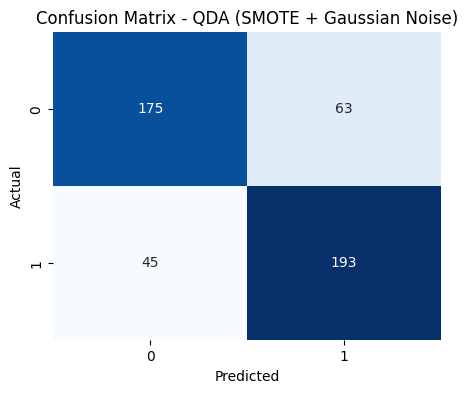

ROC AUC: 0.8565426170468188


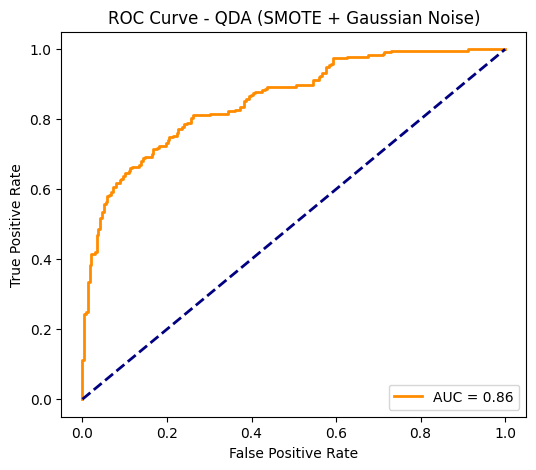

In [2]:
!pip install imbalanced-learn scikit-learn numpy pandas matplotlib seaborn

import pandas as pd
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, cohen_kappa_score,
    mean_absolute_error, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/MACCS2_Trainset_top20.csv")
X = df.drop("BioactivityClass", axis=1)
y = df["BioactivityClass"]

print("Original dataset shape:", Counter(y))


smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)


noise = np.random.normal(0, 0.01, X_smote.shape)
X_smote_noisy = X_smote + noise

print("Resampled dataset shape (SMOTE + noise):", Counter(y_smote))

X_train, X_test, y_train, y_test = train_test_split(
    X_smote_noisy, y_smote, test_size=0.3, random_state=42, stratify=y_smote
)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train_scaled, y_train)


y_pred = qda.predict(X_test_scaled)
y_proba = qda.predict_proba(X_test_scaled)[:, 1] if len(qda.classes_) == 2 else None


print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Cohen's Kappa:", cohen_kappa_score(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - QDA (SMOTE + Gaussian Noise)")
plt.show()

if y_proba is not None:
    roc_auc = roc_auc_score(y_test, y_proba)
    print("ROC AUC:", roc_auc)

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}', color='darkorange', lw=2)
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--', lw=2)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - QDA (SMOTE + Gaussian Noise)")
    plt.legend(loc="lower right")
    plt.show()

In [3]:

metrics = {
    "Accuracy": [accuracy_score(y_test, y_pred)],
    "Balanced Accuracy": [balanced_accuracy_score(y_test, y_pred)],
    "F1 Score": [f1_score(y_test, y_pred)],
    "Cohen's Kappa": [cohen_kappa_score(y_test, y_pred)],
    "Mean Absolute Error": [mean_absolute_error(y_test, y_pred)],
}

if y_proba is not None:
    metrics["ROC AUC"] = [roc_auc_score(y_test, y_proba)]

df_metrics = pd.DataFrame(metrics)
df_metrics.to_excel("QDA_SMOTE_GNoise_metrics.xlsx", index=False)
print("\nMetrics saved to 'QDA_SMOTE_GNoise_metrics.xlsx'")

pred_counts = Counter(y_pred)
print("\nPredicted class distribution:", pred_counts)

df_pred_counts = pd.DataFrame.from_dict(pred_counts, orient="index", columns=["Count"])
df_pred_counts.to_excel("QDA_SMOTE_GNoise_pred_counts.xlsx")
print("Prediction counts saved to 'QDA_SMOTE_GNoise_pred_counts.xlsx'")





Metrics saved to 'QDA_SMOTE_GNoise_metrics.xlsx'

Predicted class distribution: Counter({np.int64(1): 256, np.int64(0): 220})
Prediction counts saved to 'QDA_SMOTE_GNoise_pred_counts.xlsx'
